## Análisis comparativo de modelos — Pronóstico de temperatura (DMQ)

Compara el modelo ganador de la familia GNN (**DCRNN**, según el test de
Diebold-Mariano en `notebooks/metodologia_entrenamiento.ipynb`) contra
**ClimaX** fine-tuneado (modelo fundacional de clima) y **SARIMA**
(mejor variante de la familia clásica ARIMA/SARIMAX, ver
`docs/analisis_resultados.md`), en los tres escenarios de horizonte
(corto=3h, medio=48h, largo=72h), sobre el conjunto de test completo
(2024-01-01 a 2026-03-31) y específicamente sobre **marzo 2026**.

> **Nota sobre la familia ARIMA**: de las 4 variantes entrenadas (ARIMA,
> SARIMA, ARIMAX, SARIMAX), **SARIMA gana consistentemente** en los 3
> horizontes y en ambos periodos (test completo y marzo 2026) — las
> exógenas meteorológicas no aportan una vez que el modelo ya captura la
> estacionalidad diaria (periodo 24h). Por eso se compara con SARIMA y no
> con SARIMAX, pese a que el notebook original anticipaba esta última.


### 1. Configuración inicial


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks', context='paper', font_scale=1.2)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 11

# Paleta fija por modelo (mismos roles que en el resto del proyecto,
# ver src/visualization/estilo_graficas.json).
# 'SARIMA' (no 'SARIMAX'): la familia ARIMA gana con el modelo SIN exogenas
# (ver docs/analisis_resultados.md, seccion de hallazgos ARIMA) -- se 
# mantiene el mismo slot de color (#eda100, amarillo) ya reservado para
# la familia clasica en src/visualization/estilo_graficas.json.
COLOR_MODELO = {'DCRNN': '#e34948', 'ClimaX': '#008300', 'SARIMA': '#eda100', 'Real': '#0b0b0b'}

ESCENARIOS = {
    'corto': {'horizon': 3,  'seq_len': 24},
    'medio': {'horizon': 48, 'seq_len': 96},
    'largo': {'horizon': 72, 'seq_len': 168},
}

ART_DIR = Path('../artefactos')
RES_DCRNN = Path('../resultados/dcrnn')
RES_CLIMAX = Path('../resultados/climax')
RES_ARIMA = Path('../resultados/arima/predicciones')

MARZO_INICIO, MARZO_FIN = '2026-03-01', '2026-03-31 23:00:00'


def limpiar_ejes(ax, xlabel=None, ylabel=None, title=None):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if title is not None:
        ax.set_title(title, pad=8)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    return ax


def metricas(y_true, y_pred, eps=1e-2):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    err = y_pred - y_true
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))
    ss_res, ss_tot = np.sum(err ** 2), np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    mape = np.mean(np.abs(err) / np.maximum(np.abs(y_true), eps)) * 100
    return pd.Series({'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape})


### 2. Carga y alineación de predicciones

DCRNN guarda arrays `(n_ventanas, N_estaciones)` sin fecha explícita — se
reconstruye a partir de `tiempos.npy` y la convención de ventaneo
(`common.VentanaDataset`: el objetivo de la ventana `i` cae en
`tiempos[test_inicio + i + seq_len + horizon - 1]`). ClimaX ya exporta
`fechaHora` directamente, pero predice **toda la secuencia** del horizonte
(`horizon` = 0..pred_len-1); para comparar el mismo instante que DCRNN
(un único punto a `h` horas) se filtra al último paso
(`horizon == pred_len - 1`).


In [2]:
MODELOS_DISPONIBLES = ['DCRNN', 'ClimaX', 'SARIMA']

tiempos = pd.to_datetime(np.load(ART_DIR / 'tiempos.npy', allow_pickle=True))
splits = json.load(open(ART_DIR / 'splits.json'))
station_order = json.load(open(ART_DIR / 'station_order.json'))
test_a, _ = splits['test']


def cargar_dcrnn(escenario, horizon, seq_len):
    pred = np.load(RES_DCRNN / f'dcrnn_{escenario}_h{horizon}_pred_test.npy')
    real = np.load(RES_DCRNN / f'dcrnn_{escenario}_h{horizon}_true_test.npy')
    n = pred.shape[0]
    idx = test_a + np.arange(n) + seq_len + horizon - 1
    fechas = tiempos[idx]

    filas = []
    for j, est in enumerate(station_order):
        filas.append(pd.DataFrame({
            'fechaHora': fechas, 'estacion': est,
            'real': real[:, j], 'pred': pred[:, j],
        }))
    df = pd.concat(filas, ignore_index=True)
    df['modelo'], df['escenario'] = 'DCRNN', escenario
    return df


def cargar_climax(escenario, horizon):
    df = pd.read_parquet(RES_CLIMAX / 'predicciones' / f'predictions_{escenario}_plazo.parquet')
    df = df[df['horizon'] == df['horizon'].max()].copy()  # último paso -> mismo instante que DCRNN
    df = df.rename(columns={'real_temp': 'real', 'pred_temp': 'pred'})
    df['modelo'], df['escenario'] = 'ClimaX', escenario
    return df[['fechaHora', 'estacion', 'real', 'pred', 'modelo', 'escenario']]


def cargar_arima(escenario, horizon, modelo='sarima'):
    """
    Predicciones de la familia ARIMA (walk-forward hora a hora, por
    estación). A diferencia de DCRNN/ClimaX (ventanas de test fijas),
    ARIMA predice cada hora del rango 2022-2026 y aquí se recorta al
    mismo periodo de test (2024-01-01 a 2026-03-31) para que la
    comparación sea sobre el mismo conjunto de instantes.
    """
    df = pd.read_parquet(RES_ARIMA / 'predicciones_tuning_estaciones.parquet')
    df = df[(df['modelo'] == modelo) & (df['horizonte'] == horizon)].copy()
    df = df[(df['fechaHora'] >= '2024-01-01') & (df['fechaHora'] <= '2026-03-31 23:00:00')]
    df['modelo'], df['escenario'] = 'SARIMA', escenario
    return df[['fechaHora', 'estacion', 'real', 'pred', 'modelo', 'escenario']]


partes = []
for escenario, cfg in ESCENARIOS.items():
    if 'DCRNN' in MODELOS_DISPONIBLES:
        partes.append(cargar_dcrnn(escenario, cfg['horizon'], cfg['seq_len']))
    if 'ClimaX' in MODELOS_DISPONIBLES:
        partes.append(cargar_climax(escenario, cfg['horizon']))
    if 'SARIMA' in MODELOS_DISPONIBLES:
        partes.append(cargar_arima(escenario, cfg['horizon']))

df_todos = pd.concat(partes, ignore_index=True)
df_todos['fechaHora'] = pd.to_datetime(df_todos['fechaHora'])
print(f"Filas totales: {len(df_todos):,}")
print(df_todos.groupby(['modelo', 'escenario']).size())


Filas totales: 761,016
modelo  escenario
ClimaX  corto         39402
        largo          4908
        medio          9828
DCRNN   corto        118068
        largo        116790
        medio        117366
SARIMA  corto        118218
        largo        118218
        medio        118218
dtype: int64


### 3. Métricas globales por modelo y escenario (test completo, 2024–2026)


In [3]:
tabla_global = (
    df_todos.groupby(['escenario', 'modelo'])
    .apply(lambda g: metricas(g['real'], g['pred']))
    .reset_index()
)
orden_esc = ['corto', 'medio', 'largo']
tabla_global['escenario'] = pd.Categorical(tabla_global['escenario'], orden_esc, ordered=True)
tabla_global = tabla_global.sort_values(['escenario', 'modelo']).reset_index(drop=True)
tabla_global


/tmp/ipykernel_18501/697817573.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: metricas(g['real'], g['pred']))


,escenario,modelo,MAE,RMSE,R2,MAPE
0,corto,ClimaX,1.566686,2.124465,0.626244,9.548275
1,corto,DCRNN,0.657270,0.945809,0.926178,4.266215
2,corto,SARIMA,0.807540,1.139163,0.892871,5.238003
3,medio,ClimaX,1.798428,2.407189,0.599932,10.088580
4,medio,DCRNN,1.040084,1.405363,0.837341,6.881529
5,medio,SARIMA,1.063426,1.425416,0.832268,7.001436
6,largo,ClimaX,1.180276,1.490839,-0.294904,8.664667
7,largo,DCRNN,1.093958,1.453644,0.826066,7.164570
8,largo,SARIMA,1.078166,1.443939,0.827880,7.095029


### 4. Métricas por estación (test completo)


In [4]:
tabla_estacion = (
    df_todos.groupby(['escenario', 'modelo', 'estacion'])
    .apply(lambda g: metricas(g['real'], g['pred']))
    .reset_index()
)
tabla_estacion['escenario'] = pd.Categorical(tabla_estacion['escenario'], orden_esc, ordered=True)
tabla_estacion = tabla_estacion.sort_values(['escenario', 'modelo', 'estacion']).reset_index(drop=True)
tabla_estacion


/tmp/ipykernel_18501/1409514886.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: metricas(g['real'], g['pred']))


,escenario,modelo,estacion,MAE,RMSE,R2,MAPE
0,corto,ClimaX,Belisario,0.989768,1.348919,0.806071,7.077876
1,corto,ClimaX,Carapungo,1.136218,1.417061,0.803585,7.262430
2,corto,ClimaX,Cotocollao,1.006989,1.293668,0.813462,7.006512
3,corto,ClimaX,ElCamal,1.091806,1.404596,0.752501,7.402059
4,corto,ClimaX,LosChillos,2.342754,2.868829,0.451388,13.103021
5,corto,ClimaX,Tumbaco,2.832584,3.372805,0.179480,15.437753
6,corto,DCRNN,Belisario,0.655494,0.926480,0.908744,4.634819
7,corto,DCRNN,Carapungo,0.624644,0.880752,0.923858,4.020365
8,corto,DCRNN,Cotocollao,0.612883,0.877567,0.913026,4.212649
9,corto,DCRNN,ElCamal,0.604308,0.881009,0.903433,4.147857


### 5. Métricas de marzo 2026 (criterio de selección del mejor modelo)

Se usa específicamente marzo 2026 —el mes más reciente y completo del
conjunto de test— como criterio de desempate final entre modelos.


In [5]:
df_marzo = df_todos[(df_todos['fechaHora'] >= MARZO_INICIO) & (df_todos['fechaHora'] <= MARZO_FIN)]

tabla_marzo = (
    df_marzo.groupby(['escenario', 'modelo'])
    .apply(lambda g: metricas(g['real'], g['pred']))
    .reset_index()
)
tabla_marzo['escenario'] = pd.Categorical(tabla_marzo['escenario'], orden_esc, ordered=True)
tabla_marzo = tabla_marzo.sort_values(['escenario', 'modelo']).reset_index(drop=True)
tabla_marzo


/tmp/ipykernel_18501/1045834026.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: metricas(g['real'], g['pred']))


,escenario,modelo,MAE,RMSE,R2,MAPE
0,corto,ClimaX,1.602397,2.184665,0.580068,9.733783
1,corto,DCRNN,0.628946,0.902945,0.928637,4.057596
2,corto,SARIMA,0.785346,1.119550,0.890375,5.087744
3,medio,ClimaX,1.767779,2.344904,0.583877,9.883238
4,medio,DCRNN,0.936499,1.288760,0.854624,6.276609
5,medio,SARIMA,1.001135,1.364384,0.837184,6.543898
6,largo,ClimaX,1.140730,1.433545,-0.355815,8.345396
7,largo,DCRNN,0.992833,1.361175,0.837828,6.480799
8,largo,SARIMA,1.018459,1.385054,0.832213,6.653947


In [6]:
# Mejor modelo por escenario según MAE de marzo 2026
mejor_por_escenario = (
    tabla_marzo.sort_values('MAE')
    .groupby('escenario', observed=True)
    .first()[['modelo', 'MAE', 'RMSE', 'R2', 'MAPE']]
)
print("Mejor modelo por escenario (marzo 2026, criterio MAE):")
mejor_por_escenario


Mejor modelo por escenario (marzo 2026, criterio MAE):


,modelo,MAE,RMSE,R2,MAPE
escenario,,,,,
corto,DCRNN,0.628946,0.902945,0.928637,4.057596
medio,DCRNN,0.936499,1.288760,0.854624,6.276609
largo,DCRNN,0.992833,1.361175,0.837828,6.480799


### 5b. Significancia estadística — test de Diebold-Mariano (SARIMA vs. DCRNN)

A diferencia de la comparación A3T-GCN vs. DCRNN (mismo ventaneo, arrays ya
alineados 1:1), SARIMA y DCRNN vienen de pipelines distintos: SARIMA predice
hora a hora sobre `fechaHora` real, DCRNN predice por posición dentro del
split de test. El script de evaluación correspondiente alinea ambos por
**inner join en (fechaHora, estación)** — no por posición — reutilizando
las funciones estadísticas genéricas del test A3T-GCN vs. DCRNN (misma
corrección de muestra pequeña de Harvey-Leybourne-Newbold y misma
estimación de varianza de largo plazo con lags hasta `h-1`).

La cobertura del join fue del **100% del conjunto de test de DCRNN** en los
tres escenarios — SARIMA predijo cada instante que DCRNN también evaluó, sin
recortes por el walk-forward. El test es plenamente viable (no hace falta
degradar a una comparación solo por métricas puntuales).


In [7]:
import subprocess

subprocess.run(
    [
        'python3', '../src/evaluation/test_diebold_mariano_arima.py',
        '--arima', '../resultados/arima/predicciones',
        '--dcrnn', '../resultados/dcrnn',
        '--artefactos', '../artefactos',
        '--salida', '../resultados/diebold_mariano',
    ],
    check=True,
)

df_dm_arima = pd.read_csv('../resultados/diebold_mariano/dm_resumen_arima.csv')
df_dm_arima['escenario'] = pd.Categorical(df_dm_arima['escenario'], orden_esc, ordered=True)
df_dm_arima = df_dm_arima.sort_values('escenario').reset_index(drop=True)
df_dm_arima


 TEST DE DIEBOLD-MARIANO  |  SARIMA (modelo 1)  vs  DCRNN (modelo 2)
 Alineación: inner join por (fechaHora, estacion), no por posición
 Pérdida principal: |error| | alpha=0.05

### CORTO (h=3)  instantes alineados: 19677  (cobertura DCRNN: 100.0%)
  MAE global: SARIMA 0.8074 °C | DCRNN 0.6573 °C
  GLOBAL: dbar=+0.15016 DM=+28.252 p=3.61e-172 -> DCRNN mejor
    Belisario      21.882    6.9e-105   DCRNN mejor
    Carapungo      17.942    2.04e-71   DCRNN mejor
    Cotocollao     20.521    1.29e-92   DCRNN mejor
    ElCamal        17.362    5.03e-67   DCRNN mejor
    LosChillos     26.667   6.14e-154   DCRNN mejor
    Tumbaco        26.132   5.29e-148   DCRNN mejor

### MEDIO (h=48)  instantes alineados: 19560  (cobertura DCRNN: 100.0%)
  MAE global: SARIMA 1.0637 °C | DCRNN 1.0401 °C
  GLOBAL: dbar=+0.02362 DM=+1.641 p=0.101 -> equivalentes
    Belisario       1.943       0.052   equivalentes
    Carapungo       0.253         0.8   equivalentes
    Cotocollao      1.078       0.281   eq

,escenario,h,T,mae_SARIMA,mae_DCRNN,dm_stat,p_value,veredicto
0,corto,3,19677,0.807443,0.657281,28.252245,3.611500e-172,DCRNN mejor
1,medio,48,19560,1.063742,1.040120,1.640504,1.009164e-01,equivalentes
2,largo,72,19464,1.079446,1.094000,-1.055365,2.912714e-01,equivalentes


### 5c. Diebold-Mariano por pares — los 3 modelos, densidad de muestreo igualada

La sección 5b compara SARIMA contra DCRNN usando el 100% de las ventanas
horarias de DCRNN. Para incluir a **ClimaX** en el mismo test hay un
problema previo: ClimaX solo predice sobre ventanas **sin solapamiento**
(`stride = pred_len`), mucho más espaciadas que el ventaneo hora a hora de
DCRNN/SARIMA — no son la misma muestra, y el test DM asume observaciones
pareadas en los mismos instantes.

`src/evaluation/test_diebold_mariano_todos.py` iguala la densidad de
muestreo tomando la **intersección estricta de instantes** (fechaHora +
estación) donde los tres modelos tienen predicción — necesariamente al
ritmo más disperso de ClimaX — y corre el test DM de a pares (DCRNN-ClimaX,
DCRNN-SARIMA, ClimaX-SARIMA) sobre esa misma muestra igualada en los tres
casos.

> **Advertencia metodológica**: igualar la densidad de muestreo por
> `stride` de ClimaX tiene un costo. Como `pred_len` es múltiplo (o casi)
> de 24h en "medio" y "largo", las ventanas de ClimaX terminan cayendo casi
> siempre a la(s) misma(s) hora(s) del día. Al revisar las horas
> efectivamente muestreadas: **"corto" cubre 8 horas del día** (cada 3h,
> razonable), **"medio" queda reducido a solo 2 horas** (11:00 y 23:00), y
> **"largo" queda reducido a una sola hora del día (23:00)**. El resultado
> de "largo" en particular NO es representativo del ciclo diurno completo
> — es válido solo para pronósticos anclados a las 23:00, no una conclusión
> general sobre el horizonte de 72h. La comparación densa de la sección 5b
> (SARIMA vs. DCRNN, todas las horas) sigue siendo la referencia más
> representativa para ese par específico; esta sección es la única forma
> de incluir a ClimaX de forma válida, con esa salvedad explícita.


In [8]:
subprocess.run(
    [
        'python3', '../src/evaluation/test_diebold_mariano_todos.py',
        '--dcrnn', '../resultados/dcrnn',
        '--climax', '../resultados/climax',
        '--arima', '../resultados/arima/predicciones',
        '--artefactos', '../artefactos',
        '--salida', '../resultados/diebold_mariano',
    ],
    check=True,
)

df_dm_todos = pd.read_csv('../resultados/diebold_mariano/dm_resumen_todos.csv')
df_dm_todos['escenario'] = pd.Categorical(df_dm_todos['escenario'], orden_esc, ordered=True)
df_dm_todos = df_dm_todos.sort_values(['escenario', 'par']).reset_index(drop=True)
df_dm_todos


 TEST DE DIEBOLD-MARIANO POR PARES  |  DCRNN vs ClimaX vs SARIMA
 Densidad de muestreo igualada: interseccion estricta de instantes de los 3 modelos
 Perdida principal: |error| | alpha=0.05

### CORTO (h=3)  instantes alineados (los 3 modelos): 6559  (= 99.9% de las ventanas de ClimaX)
  DCRNN  vs ClimaX  MAE 0.6668 vs 1.5671  DM=-71.260  p=0  -> DCRNN mejor
  DCRNN  vs SARIMA  MAE 0.6668 vs 0.8248  DM=-24.160  p=1.31e-123  -> DCRNN mejor
  ClimaX vs SARIMA  MAE 1.5671 vs 0.8248  DM=+61.055  p=0  -> SARIMA mejor

### MEDIO (h=48)  instantes alineados (los 3 modelos): 1630  (= 99.5% de las ventanas de ClimaX)
  DCRNN  vs ClimaX  MAE 0.9474 vs 1.7995  DM=-32.108  p=1.13e-175  -> DCRNN mejor
  DCRNN  vs SARIMA  MAE 0.9474 vs 0.9785  DM=-3.186  p=0.00147  -> DCRNN mejor
  ClimaX vs SARIMA  MAE 1.7995 vs 0.9785  DM=+28.911  p=1.06e-148  -> SARIMA mejor

### LARGO (h=72)  instantes alineados (los 3 modelos): 811  (= 99.1% de las ventanas de ClimaX)
  DCRNN  vs ClimaX  MAE 0.7181 vs 1.1813  D

,escenario,h,T,par,mae_A,mae_B,dm_stat,p_value,veredicto
0,corto,3,6559,ClimaX-SARIMA,1.567081,0.824821,61.054859,0.000000e+00,SARIMA mejor
1,corto,3,6559,DCRNN-ClimaX,0.666847,1.567081,-71.260399,0.000000e+00,DCRNN mejor
2,corto,3,6559,DCRNN-SARIMA,0.666847,0.824821,-24.159554,1.311569e-123,DCRNN mejor
3,medio,48,1630,ClimaX-SARIMA,1.799508,0.978543,28.911348,1.057510e-148,SARIMA mejor
4,medio,48,1630,DCRNN-ClimaX,0.947434,1.799508,-32.108058,1.133977e-175,DCRNN mejor
5,medio,48,1630,DCRNN-SARIMA,0.947434,0.978543,-3.186065,1.469552e-03,DCRNN mejor
6,largo,72,811,ClimaX-SARIMA,1.181320,0.680978,5.470197,5.993490e-08,SARIMA mejor
7,largo,72,811,DCRNN-ClimaX,0.718073,1.181320,-5.153123,3.220743e-07,DCRNN mejor
8,largo,72,811,DCRNN-SARIMA,0.718073,0.680978,6.170417,1.075236e-09,SARIMA mejor


### 6. Comparación de error por escenario (marzo 2026)


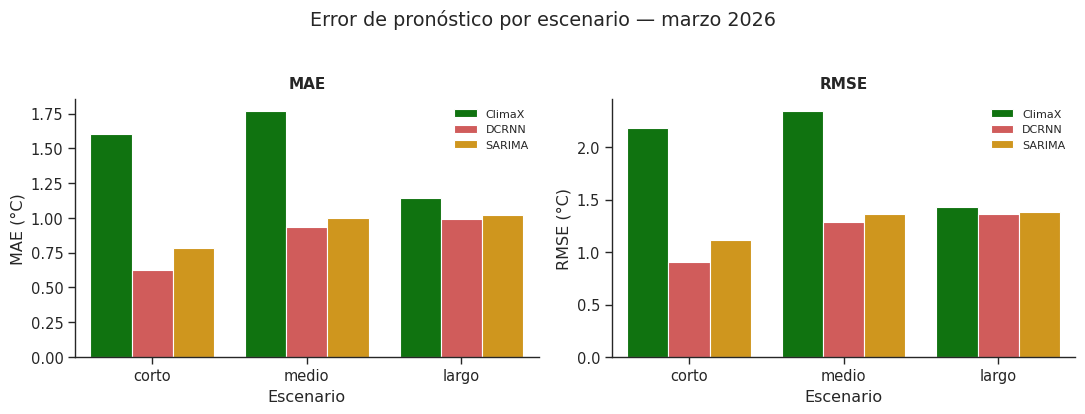

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metrica in zip(axes, ['MAE', 'RMSE']):
    sns.barplot(
        data=tabla_marzo, x='escenario', y=metrica, hue='modelo',
        palette=COLOR_MODELO, order=orden_esc, ax=ax,
    )
    limpiar_ejes(ax, xlabel='Escenario', ylabel=f'{metrica} (°C)', title=metrica)
    ax.legend(frameon=False, fontsize=8, title=None)

fig.suptitle('Error de pronóstico por escenario — marzo 2026', y=1.03)
plt.tight_layout()
plt.savefig('../docs/figuras/comparativa/barras_error.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Predicción vs. real — marzo 2026 (general, promedio entre estaciones)


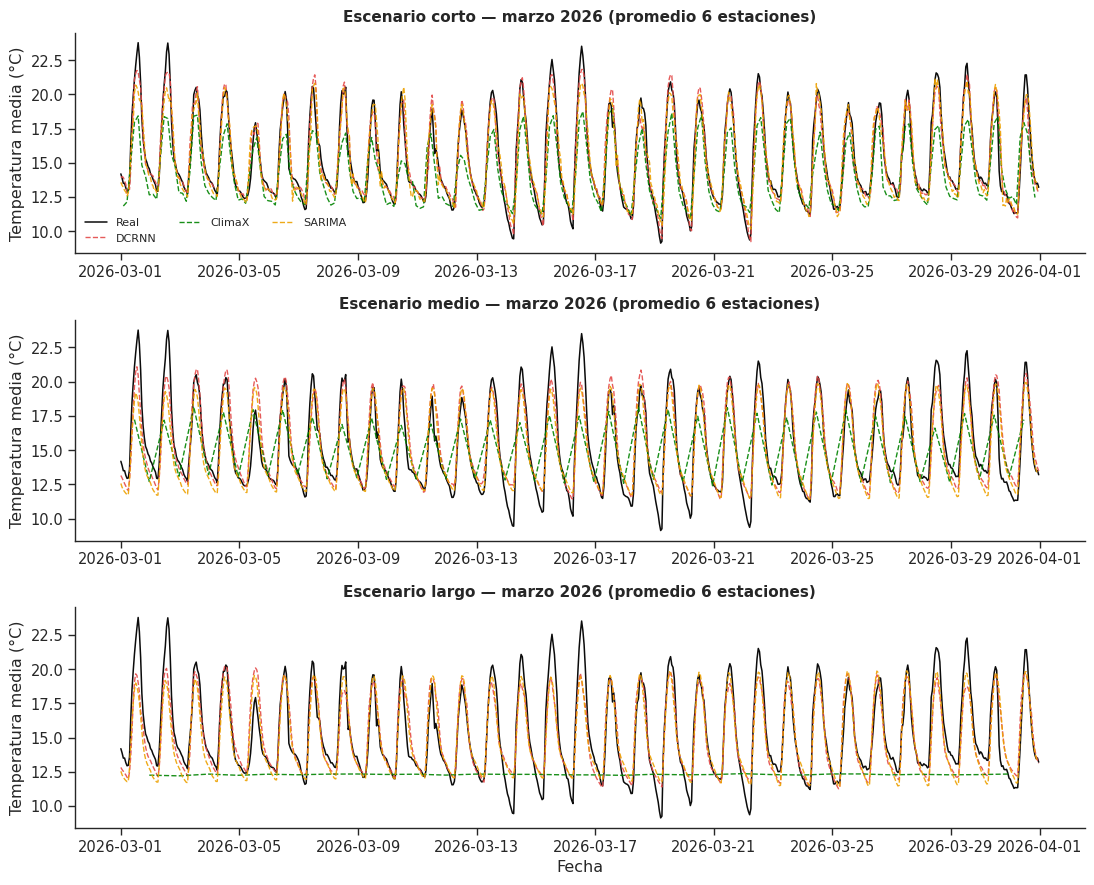

In [10]:
fig, axes = plt.subplots(len(orden_esc), 1, figsize=(11, 3 * len(orden_esc)))
for ax, escenario in zip(axes, orden_esc):
    sub = df_marzo[df_marzo['escenario'] == escenario]
    diario = sub.groupby(['fechaHora', 'modelo'])[['real', 'pred']].mean().reset_index()

    real_serie = diario.drop_duplicates('fechaHora').set_index('fechaHora')['real'].sort_index()
    ax.plot(real_serie.index, real_serie.values, color=COLOR_MODELO['Real'],
            linewidth=1.1, label='Real')

    for modelo in MODELOS_DISPONIBLES:
        s = diario[diario['modelo'] == modelo].set_index('fechaHora')['pred'].sort_index()
        ax.plot(s.index, s.values, color=COLOR_MODELO[modelo], linewidth=1.0,
                linestyle='--', alpha=0.9, label=modelo)

    limpiar_ejes(ax, ylabel='Temperatura media (°C)',
                 title=f'Escenario {escenario} — marzo 2026 (promedio 6 estaciones)')
    if ax is axes[-1]:
        ax.set_xlabel('Fecha')

axes[0].legend(frameon=False, fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig('../docs/figuras/comparativa/serie_general.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. Predicción vs. real — marzo 2026, por estación

Se muestra el escenario "corto" (el de mayor precisión y el que arrojó
diferencia estadísticamente significativa entre A3T-GCN y DCRNN) desagregado
por estación.


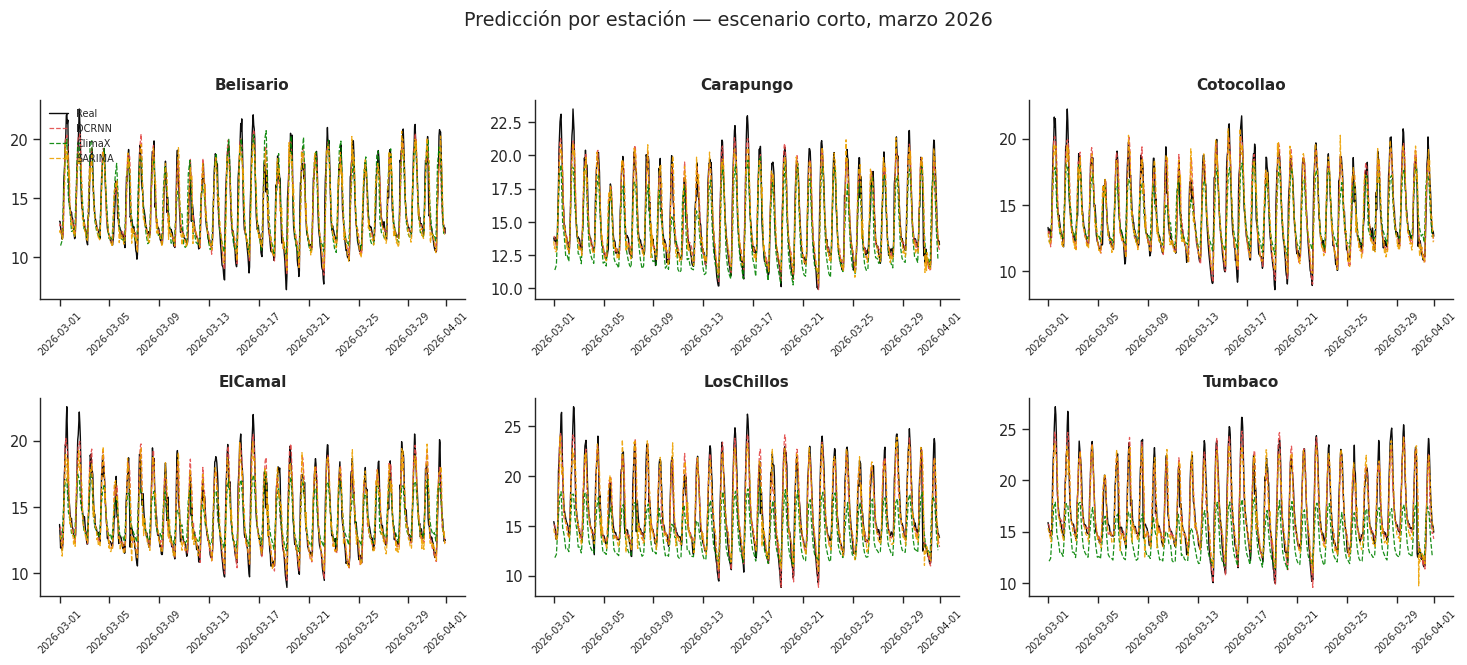

In [11]:
ESCENARIO_DETALLE = 'corto'
sub = df_marzo[df_marzo['escenario'] == ESCENARIO_DETALLE]

fig, axes = plt.subplots(2, 3, figsize=(15, 6.5))
axes = axes.flatten()
for ax, est in zip(axes, station_order):
    sub_est = sub[sub['estacion'] == est]
    real_serie = sub_est.drop_duplicates('fechaHora').set_index('fechaHora')['real'].sort_index()
    ax.plot(real_serie.index, real_serie.values, color=COLOR_MODELO['Real'], linewidth=1.0, label='Real')

    for modelo in MODELOS_DISPONIBLES:
        s = sub_est[sub_est['modelo'] == modelo].set_index('fechaHora')['pred'].sort_index()
        ax.plot(s.index, s.values, color=COLOR_MODELO[modelo], linewidth=0.9,
                linestyle='--', alpha=0.9, label=modelo)

    limpiar_ejes(ax, title=est)
    ax.tick_params(axis='x', rotation=45, labelsize=7)

axes[0].legend(frameon=False, fontsize=7)
fig.suptitle(f'Predicción por estación — escenario {ESCENARIO_DETALLE}, marzo 2026', y=1.02)
plt.tight_layout()
plt.savefig('../docs/figuras/comparativa/serie_por_estacion.png', dpi=150, bbox_inches='tight')
plt.show()


### 9. Mapa de error por estación (MAE, marzo 2026)


/tmp/ipykernel_18501/2236935273.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: metricas(g['real'], g['pred'])['MAE'])
/tmp/ipykernel_18501/2236935273.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: metricas(g['real'], g['pred'])['MAE'])
/tmp/ipykernel_18501/2236935273.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, a

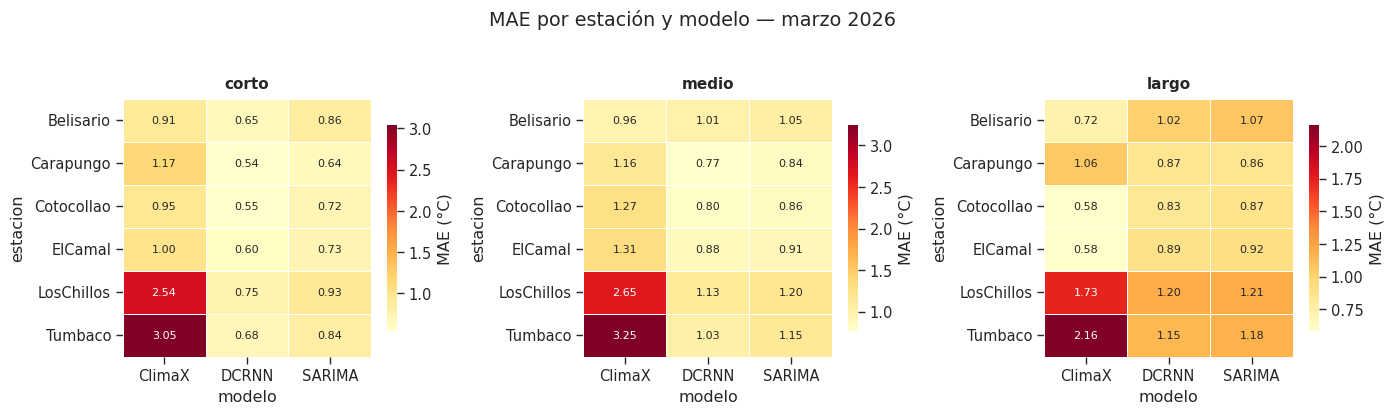

In [12]:
fig, axes = plt.subplots(1, len(orden_esc), figsize=(14, 4))
for ax, escenario in zip(axes, orden_esc):
    sub = df_marzo[df_marzo['escenario'] == escenario]
    tabla = (
        sub.groupby(['estacion', 'modelo'])
        .apply(lambda g: metricas(g['real'], g['pred'])['MAE'])
        .unstack('modelo')
    )
    sns.heatmap(tabla, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
                linewidths=0.4, linecolor='white', annot_kws={'size': 8},
                cbar_kws={'label': 'MAE (°C)', 'shrink': 0.8})
    limpiar_ejes(ax, title=escenario)

fig.suptitle('MAE por estación y modelo — marzo 2026', y=1.03)
plt.tight_layout()
plt.savefig('../docs/figuras/comparativa/heatmap_estacion.png', dpi=150, bbox_inches='tight')
plt.show()


### 9b. Comparativa por estación — gráfico de barras (los 3 modelos)

Vista complementaria al heatmap: barras agrupadas por estación, una barra
por modelo, para leer directamente la magnitud del MAE en vez de una escala
de color — más fácil de citar puntualmente en el TFM.


/tmp/ipykernel_18501/402269378.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: metricas(g['real'], g['pred'])['MAE'])
/tmp/ipykernel_18501/402269378.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: metricas(g['real'], g['pred'])['MAE'])
/tmp/ipykernel_18501/402269378.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and 

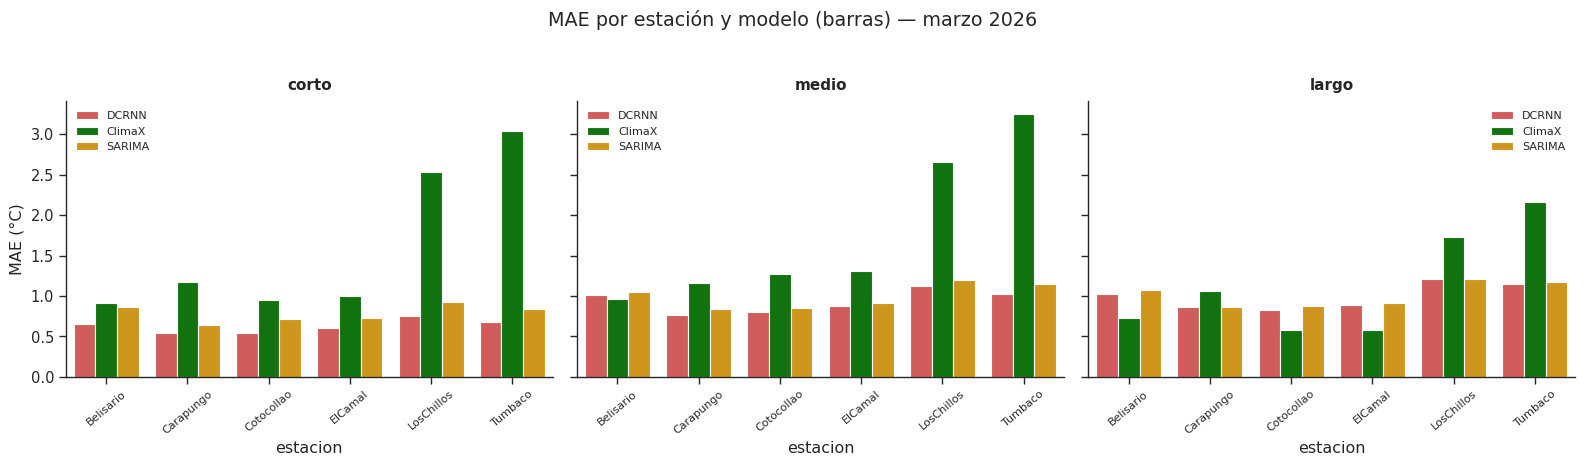

In [13]:
fig, axes = plt.subplots(1, len(orden_esc), figsize=(16, 4.5), sharey=True)
for ax, escenario in zip(axes, orden_esc):
    sub = df_marzo[df_marzo['escenario'] == escenario]
    tabla_bar = (
        sub.groupby(['estacion', 'modelo'])
        .apply(lambda g: metricas(g['real'], g['pred'])['MAE'])
        .reset_index(name='MAE')
    )
    sns.barplot(
        data=tabla_bar, x='estacion', y='MAE', hue='modelo',
        palette=COLOR_MODELO, hue_order=MODELOS_DISPONIBLES, ax=ax,
    )
    limpiar_ejes(ax, xlabel=None, ylabel='MAE (°C)' if ax is axes[0] else None, title=escenario)
    ax.tick_params(axis='x', rotation=40, labelsize=8)
    ax.legend(frameon=False, fontsize=8, title=None)

fig.suptitle('MAE por estación y modelo (barras) — marzo 2026', y=1.03)
plt.tight_layout()
plt.savefig('../docs/figuras/comparativa/barras_estacion.png', dpi=150, bbox_inches='tight')
plt.show()


### 10. Conclusión

Con el criterio de MAE sobre marzo 2026 (tabla `mejor_por_escenario`,
sección 5) y el test de Diebold-Mariano (sección 5b), el panorama de tres
familias de modelos es:

- **Corto plazo (h=3)**: DCRNN gana con significancia estadística muy alta
  (p ≈ 3.6e-172) sobre SARIMA, y por métricas puntuales sobre ClimaX.
- **Medio plazo (h=48)**: DCRNN sigue mejor en métricas puntuales, pero el
  test DM muestra que la diferencia frente a SARIMA **no es
  estadísticamente significativa** (p ≈ 0.10) — ambos modelos son
  estadísticamente equivalentes en este horizonte.
- **Largo plazo (h=72)**: SARIMA tiene incluso un MAE global ligeramente
  menor que DCRNN, pero tampoco la diferencia es significativa (p ≈ 0.29) —
  de nuevo equivalentes. ClimaX queda por detrás de ambos en métricas
  puntuales, arrastrado por su entrenamiento truncado a 26 épocas.

**Lectura principal**: la ventaja de DCRNN sobre los métodos estadísticos
clásicos es real y significativa a corto plazo, pero **se diluye a medida
que crece el horizonte** — a partir de 48h, un SARIMA simple (sin variables
exógenas) predice, en términos estadísticos, igual de bien que la red
neuronal espacio-temporal. Esto matiza cualquier conclusión de "el modelo
más complejo siempre gana": la complejidad adicional de DCRNN paga
dividendos claros solo en la ventana de pronóstico más corta.
